In [2]:
# Load ground truth data
import pandas as pd

bf_data = pd.read_csv('results/pickblueblock_bruteforce/results.csv')
print(f"Loaded ground truth data: {len(bf_data)} points")
print(f"Factor columns: {list(bf_data.columns)}")

Loaded ground truth data: 804 points
Factor columns: ['trial', 'mode', 'binary_outcome', 'continuous_outcome', 'steps_taken', 'x', 'y', 'table_height', 'camera_azimuth', 'camera_elevation', 'camera_distance']


In [11]:
# Load active model
import pickle

model_path = '/home/liao0241/active_testing/results/pickblueblock_active_offline_SingleTaskGP_PSD/models/final_model.pkl'

with open(model_path, 'rb') as f:
    active_model_data = pickle.load(f)
    active_model = active_model_data['model']
    active_model_name = active_model_data.get('model_name', 'Unknown')
print(f"Loaded active model: {active_model_name}")

Loaded active model: SingleTaskGP


In [6]:
# Load IID results and model
iid_results_path = '/home/liao0241/active_testing/results/pickblueblock_iid_offline_SingleTaskGP/results.csv'
iid_data = pd.read_csv(iid_results_path)

# Load IID model if available
iid_model_path = '/home/liao0241/active_testing/results/pickblueblock_iid_offline_SingleTaskGP/models/trial_50_model.pkl'
iid_model = None
iid_model_name = 'SingleTaskGP'  # Default model name

with open(iid_model_path, 'rb') as f:
    iid_model_data = pickle.load(f)
    iid_model = iid_model_data['model']
    iid_model_name = iid_model_data.get('model_name', 'Unknown')
print(f"Loaded IID model: {iid_model_name}")

Loaded IID model: SingleTaskGP


In [7]:
# Imports for violin plot and cross-validation
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from factors_config import FACTOR_COLUMNS, get_design_points_robot, BOUNDS, tkwargs
from utils import fit_surrogate_model, calculate_rmse

In [8]:
# 1. Violin plot: Model predictions vs Ground Truth (grouped by discrete ground truth values)

def plot_predictions_vs_ground_truth(model, bf_data, model_name="Model"):
    """
    Creates a violin plot showing distribution of model predictions for each discrete ground truth value.
    
    Args:
        model: Trained BoTorch model
        bf_data: DataFrame with ground truth data (must contain FACTOR_COLUMNS and 'continuous_outcome')
        model_name: Name of the model for the plot title
    """
    # Get all design space points
    all_points = get_design_points_robot()  # Shape: [N, D]
    
    # Convert to DataFrame for easier matching
    all_points_df = pd.DataFrame(all_points.numpy(), columns=FACTOR_COLUMNS)
    
    # Merge with ground truth data to get outcomes for matching factor combinations
    # Merge on all factor columns
    merged = all_points_df.merge(
        bf_data[FACTOR_COLUMNS + ['continuous_outcome']],
        on=FACTOR_COLUMNS,
        how='inner'
    )
    
    if len(merged) == 0:
        print("Warning: No matching factor combinations found between design space and ground truth data.")
        return None
    
    print(f"Found {len(merged)} matching factor combinations out of {len(all_points)} total design points.")
    
    # Get ground truth values
    y_true = merged['continuous_outcome'].values
    
    # Get factor values for predictions
    X_pred = torch.tensor(merged[FACTOR_COLUMNS].values, **tkwargs)
    
    # Make predictions
    with torch.no_grad():
        posterior = model.posterior(X_pred)
        pred_mean = posterior.mean.squeeze(-1)
        # Handle Bayesian models with multiple samples
        if pred_mean.ndim == 2:
            pred_mean = pred_mean.mean(dim=0)  # Average over samples
        y_pred = pred_mean.cpu().numpy()
    
    # Get unique ground truth values and sort them
    unique_gt = sorted(merged['continuous_outcome'].unique())
    print(f"Unique ground truth values: {unique_gt}")
    
    # Create violin plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Prepare data for violin plot
    data_for_violin = []
    positions = []
    labels = []
    for i, gt_val in enumerate(unique_gt):
        mask = merged['continuous_outcome'] == gt_val
        preds_for_gt = y_pred[mask]
        data_for_violin.append(preds_for_gt)
        positions.append(i)
        labels.append(f'{gt_val:.1f}')
    
    # Create violin plot
    parts = ax.violinplot(data_for_violin, positions=positions, widths=0.6, 
                          showmeans=True, showmedians=True)
    
    # Customize violin plot colors
    for pc in parts['bodies']:
        pc.set_facecolor('lightblue')
        pc.set_alpha(0.7)
    
    # Set x-axis labels
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    
    # Labels and title
    ax.set_xlabel('Ground Truth (continuous_outcome)', fontsize=12)
    ax.set_ylabel('Model Predictions', fontsize=12)
    ax.set_title(f'{model_name}: Predictions vs Ground Truth\n(N={len(merged)} factor combinations)', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Calculate and display metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    
    # Add text box with metrics
    textstr = f'RMSE: {rmse:.3f}\nMAE: {mae:.3f}\nR²: {r2:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
             verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()
    
    return y_true, y_pred, rmse, mae, r2


def plot_predictions_vs_ground_truth_scatter(model, bf_data, model_name="Model"):
    """
    Creates a scatter plot showing model predictions vs ground truth for all factor combinations.
    
    Args:
        model: Trained BoTorch model
        bf_data: DataFrame with ground truth data (must contain FACTOR_COLUMNS and 'continuous_outcome')
        model_name: Name of the model for the plot title
    
    Returns:
        y_true, y_pred, rmse, mae, r2: Ground truth values, predictions, and metrics
    """
    # Get all design space points
    all_points = get_design_points_robot()  # Shape: [N, D]
    
    # Convert to DataFrame for easier matching
    all_points_df = pd.DataFrame(all_points.numpy(), columns=FACTOR_COLUMNS)
    
    # Merge with ground truth data to get outcomes for matching factor combinations
    # Merge on all factor columns
    merged = all_points_df.merge(
        bf_data[FACTOR_COLUMNS + ['continuous_outcome']],
        on=FACTOR_COLUMNS,
        how='inner'
    )
    
    if len(merged) == 0:
        print("Warning: No matching factor combinations found between design space and ground truth data.")
        return None
    
    print(f"Found {len(merged)} matching factor combinations out of {len(all_points)} total design points.")
    
    # Get ground truth values
    y_true = merged['continuous_outcome'].values
    
    # Get factor values for predictions
    X_pred = torch.tensor(merged[FACTOR_COLUMNS].values, **tkwargs)
    
    # Make predictions
    with torch.no_grad():
        posterior = model.posterior(X_pred)
        pred_mean = posterior.mean.squeeze(-1)
        # Handle Bayesian models with multiple samples
        if pred_mean.ndim == 2:
            pred_mean = pred_mean.mean(dim=0)  # Average over samples
        y_pred = pred_mean.cpu().numpy()
    
    # Create scatter plot
    plt.figure(figsize=(10, 8))
    plt.scatter(y_true, y_pred, alpha=0.6, s=50)
    
    # Add diagonal line (perfect predictions)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect predictions')
    
    # Labels and title
    plt.xlabel('Ground Truth (continuous_outcome)', fontsize=12)
    plt.ylabel('Model Predictions', fontsize=12)
    plt.title(f'{model_name}: Predictions vs Ground Truth\n(N={len(merged)} factor combinations)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Calculate and display metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    
    # Add text box with metrics
    textstr = f'RMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
             verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()
    
    return y_true, y_pred, rmse, mae, r2


ACTIVE MODEL ANALYSIS
Generated 1089 total design points (11x11x3x3 = 1089).
Found 666 matching factor combinations out of 1089 total design points.
Unique ground truth values: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0)]


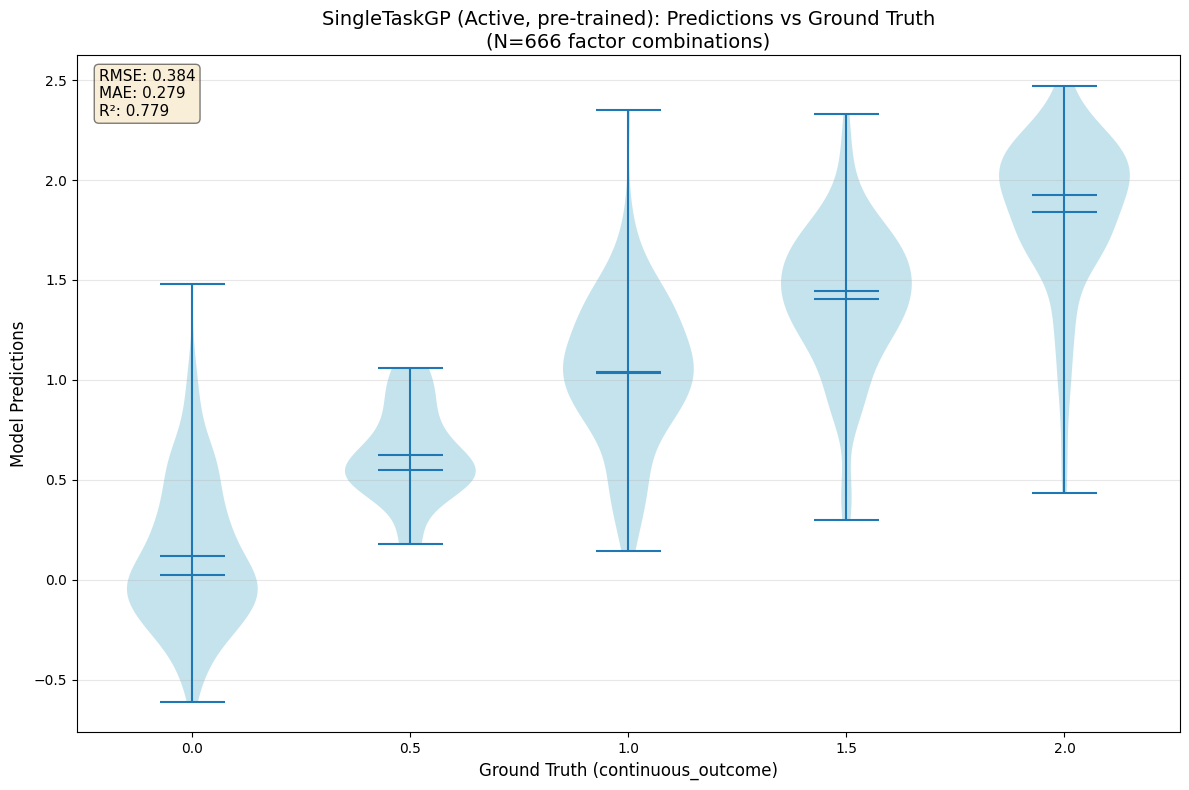

In [ ]:
# Run violin plot analysis: Active model predictions vs ground truth
print("\n" + "="*60)
print("ACTIVE MODEL ANALYSIS")
print("="*60)
active_violin_results = plot_predictions_vs_ground_truth(
    active_model, 
    bf_data, 
    model_name=f"{active_model_name} (Active, pre-trained)"
)

Generated 1089 total design points (11x11x3x3 = 1089).
Found 666 matching factor combinations out of 1089 total design points.


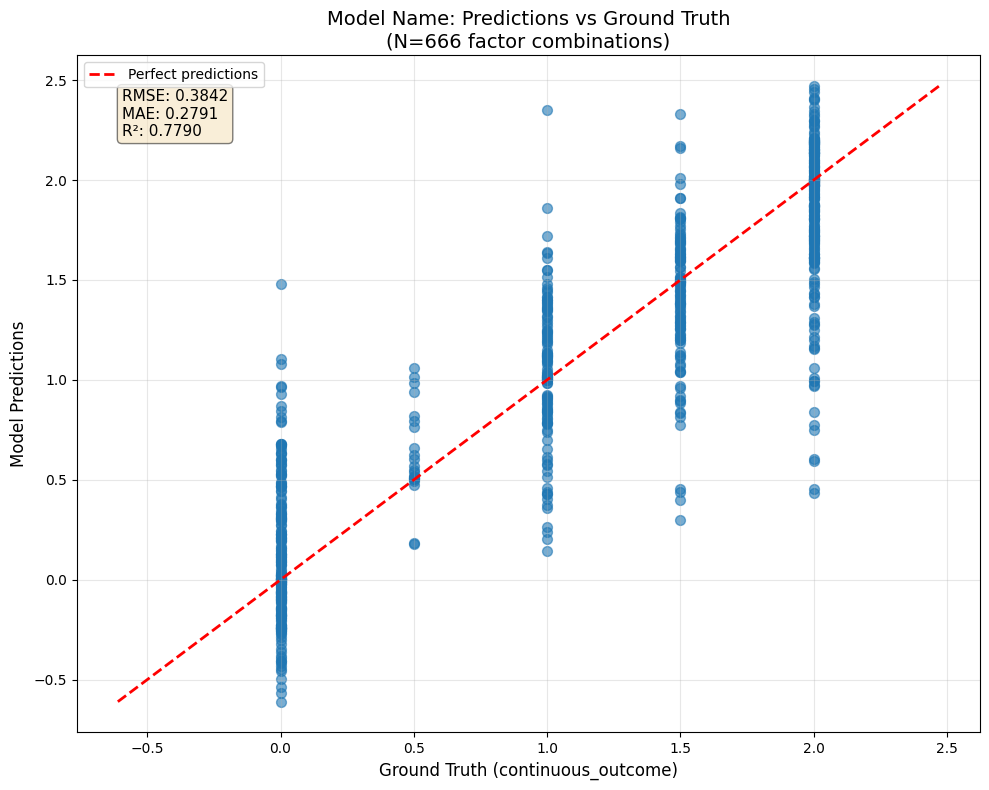

In [ ]:
active_scatter_results = plot_predictions_vs_ground_truth_scatter(
    active_model, 
    bf_data, 
    model_name=f"{active_model_name} (Active, pre-trained)"
)


IID MODEL ANALYSIS
Generated 1089 total design points (11x11x3x3 = 1089).
Found 666 matching factor combinations out of 1089 total design points.
Unique ground truth values: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0)]


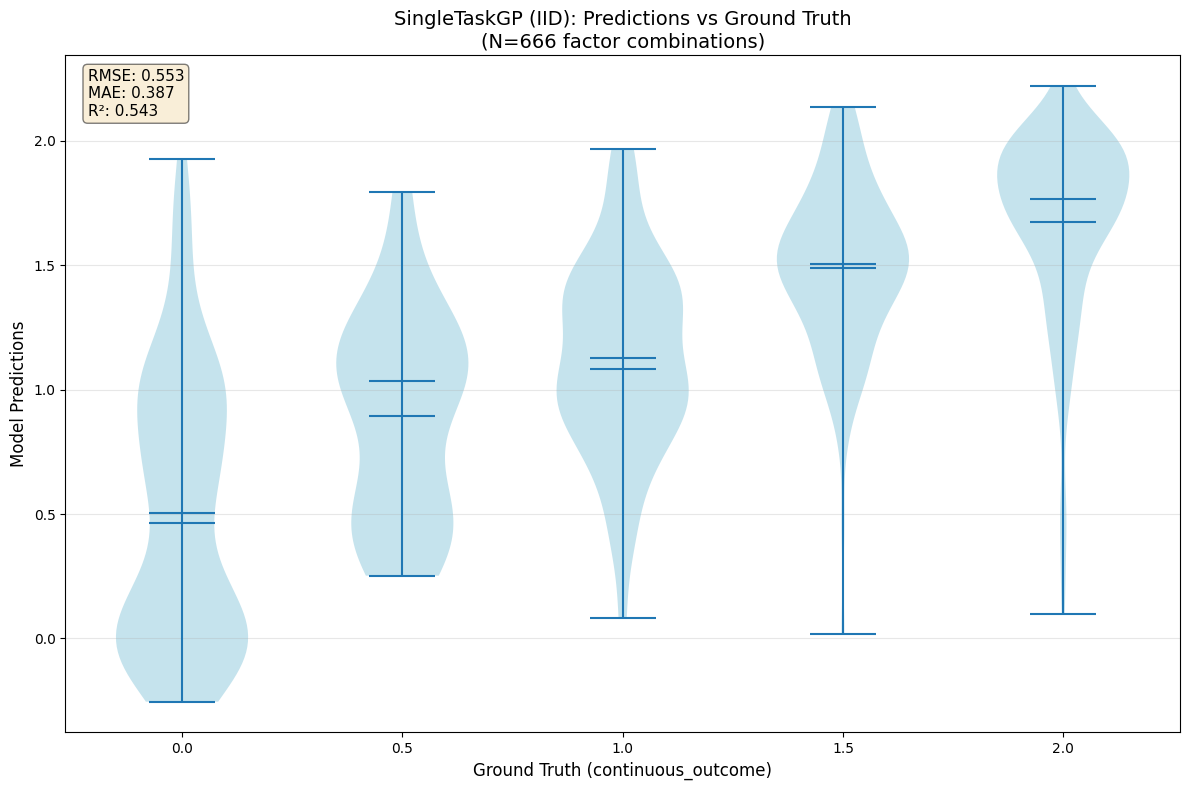

In [14]:
# Run violin plot analysis: IID model predictions vs ground truth
print("\n" + "="*60)
print("IID MODEL ANALYSIS")
print("="*60)

# If IID model not loaded, train one from IID data
if iid_model is None:
    print("Training IID model from IID results...")
    X_iid = torch.tensor(iid_data[FACTOR_COLUMNS].values, **tkwargs)
    y_iid = torch.tensor(iid_data['continuous_outcome'].values, **tkwargs).unsqueeze(-1)
    iid_model = fit_surrogate_model(X_iid, y_iid, BOUNDS, model_name=iid_model_name)
    print("IID model trained successfully.")

iid_results = plot_predictions_vs_ground_truth(
    iid_model,
    bf_data,
    model_name=f"{iid_model_name} (IID)"
)

Generated 1089 total design points (11x11x3x3 = 1089).
Found 666 matching factor combinations out of 1089 total design points.


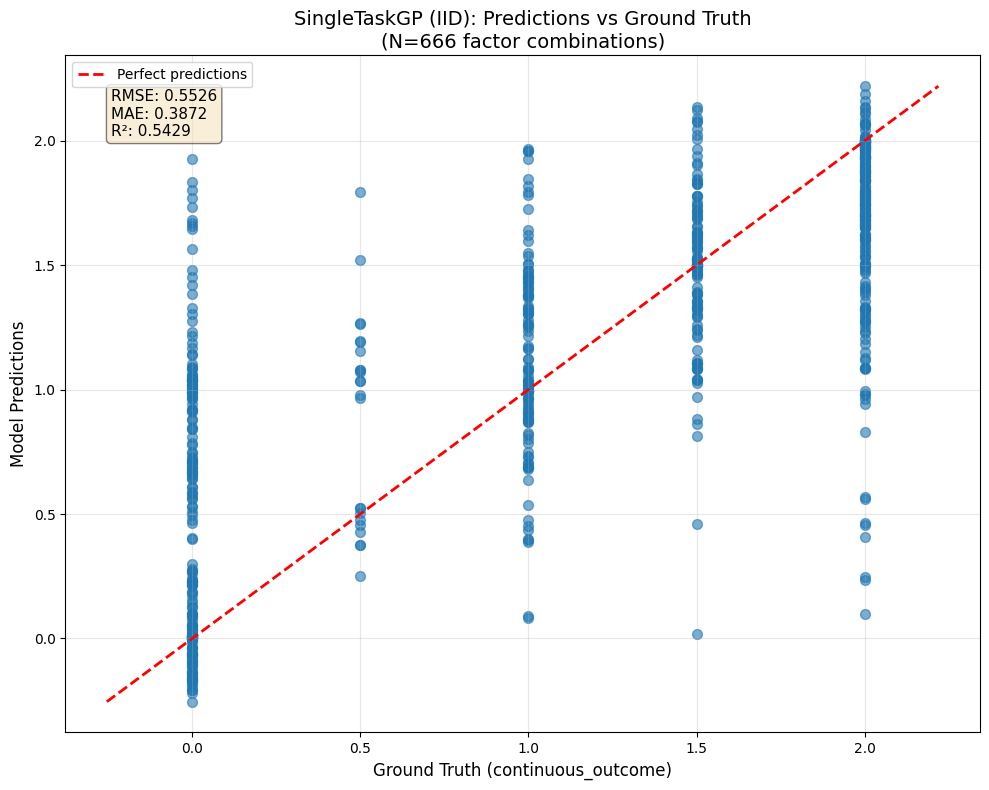

In [16]:
iid_scatter_results = plot_predictions_vs_ground_truth_scatter(
    iid_model, 
    bf_data, 
    model_name=f"{iid_model_name} (IID)"
)

In [17]:
# 2. Cross-validation: m repetitions of n%/(100-n)% train-test splits

def cross_validate_model(bf_data, model_name, m=10, train_split=0.8, random_state=None):
    """
    Performs m-fold cross-validation with n% train / (100-n)% test splits.
    
    Args:
        bf_data: DataFrame with ground truth data (must contain FACTOR_COLUMNS and 'continuous_outcome')
        model_name: Name of the model to use (e.g., 'SingleTaskGP', 'FullyBayesianSingleTaskGP')
        m: Number of repetitions/folds
        train_split: Fraction of data to use for training (e.g., 0.8 for 80% train, 20% test)
        random_state: Random seed for reproducibility (None for different splits each time)
    
    Returns:
        Dictionary with metrics for each fold and summary statistics
    """
    results = {
        'fold': [],
        'train_size': [],
        'test_size': [],
        'train_rmse': [],
        'test_rmse': [],
        'test_mae': [],
        'test_r2': []
    }
    
    # Prepare data
    X_all = torch.tensor(bf_data[FACTOR_COLUMNS].values, **tkwargs)
    y_all = torch.tensor(bf_data['continuous_outcome'].values, **tkwargs).unsqueeze(-1)
    
    print(f"Cross-validation: {m} repetitions, {train_split*100:.1f}% train / {(1-train_split)*100:.1f}% test")
    print(f"Total data points: {len(bf_data)}")
    print("-" * 60)
    
    for fold in range(m):
        # Create train-test split
        if random_state is not None:
            rs = random_state + fold
        else:
            rs = None
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_all.numpy(), y_all.numpy().flatten(),
            train_size=train_split,
            random_state=rs,
            shuffle=True
        )
        
        # Convert back to tensors
        X_train = torch.tensor(X_train, **tkwargs)
        y_train = torch.tensor(y_train, **tkwargs).unsqueeze(-1)
        X_test = torch.tensor(X_test, **tkwargs)
        y_test = torch.tensor(y_test, **tkwargs).unsqueeze(-1)
        
        # Fit model
        train_X = X_train
        train_Y = y_train
        
        try:
            fitted_model = fit_surrogate_model(train_X, train_Y, BOUNDS, model_name=model_name)
            
            # Evaluate on train set
            train_rmse = calculate_rmse(fitted_model, train_X, train_Y)
            
            # Evaluate on test set
            test_rmse = calculate_rmse(fitted_model, X_test, y_test)
            
            # Calculate additional metrics on test set
            with torch.no_grad():
                posterior = fitted_model.posterior(X_test)
                pred_mean = posterior.mean.squeeze(-1)
                if pred_mean.ndim == 2:
                    pred_mean = pred_mean.mean(dim=0)
                y_pred = pred_mean.cpu().numpy()
                y_true = y_test.cpu().numpy().flatten()
            
            test_mae = np.mean(np.abs(y_true - y_pred))
            test_r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
            
            # Store results
            results['fold'].append(fold + 1)
            results['train_size'].append(len(X_train))
            results['test_size'].append(len(X_test))
            results['train_rmse'].append(train_rmse)
            results['test_rmse'].append(test_rmse)
            results['test_mae'].append(test_mae)
            results['test_r2'].append(test_r2)
            
            print(f"Fold {fold+1}/{m}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f}, Test R²={test_r2:.4f}")
            
        except Exception as e:
            print(f"Fold {fold+1}/{m}: Error - {e}")
            continue
    
    # Convert to DataFrame for easier analysis
    results_df = pd.DataFrame(results)
    
    # Print summary statistics
    print("\n" + "=" * 60)
    print("Cross-Validation Summary Statistics:")
    print("=" * 60)
    print(f"Train RMSE: {results_df['train_rmse'].mean():.4f} ± {results_df['train_rmse'].std():.4f}")
    print(f"Test RMSE:  {results_df['test_rmse'].mean():.4f} ± {results_df['test_rmse'].std():.4f}")
    print(f"Test MAE:   {results_df['test_mae'].mean():.4f} ± {results_df['test_mae'].std():.4f}")
    print(f"Test R²:    {results_df['test_r2'].mean():.4f} ± {results_df['test_r2'].std():.4f}")
    
    return results_df

# Run cross-validation analysis
# Note: This trains new models on each fold, so specify the model_name you want to evaluate
cv_results = cross_validate_model(
    bf_data, 
    model_name='SingleTaskGP',  # Change to 'FullyBayesianSingleTaskGP', 'SaasFullyBayesianSingleTaskGP', etc.
    m=10,                        # Number of repetitions
    train_split=0.2,             # n% train, (100-n)% test
    random_state=42              # For reproducibility
)

Cross-validation: 10 repetitions, 20.0% train / 80.0% test
Total data points: 804
------------------------------------------------------------
Fold 1/10: Train RMSE=0.1506, Test RMSE=0.3086, Test R²=0.8552
Fold 2/10: Train RMSE=0.1689, Test RMSE=0.3160, Test R²=0.8530
Fold 3/10: Train RMSE=0.2209, Test RMSE=0.3272, Test R²=0.8432
Fold 4/10: Train RMSE=0.1370, Test RMSE=0.3069, Test R²=0.8567
Fold 5/10: Train RMSE=0.1538, Test RMSE=0.3327, Test R²=0.8370
Fold 6/10: Train RMSE=0.1449, Test RMSE=0.3145, Test R²=0.8514
Fold 7/10: Train RMSE=0.1872, Test RMSE=0.3367, Test R²=0.8324
Fold 8/10: Train RMSE=0.1274, Test RMSE=0.3236, Test R²=0.8437
Fold 9/10: Train RMSE=0.1608, Test RMSE=0.3752, Test R²=0.7895
Fold 10/10: Train RMSE=0.1849, Test RMSE=0.3305, Test R²=0.8394

Cross-Validation Summary Statistics:
Train RMSE: 0.1636 ± 0.0278
Test RMSE:  0.3272 ± 0.0197
Test MAE:   0.2332 ± 0.0122
Test R²:    0.8401 ± 0.0196


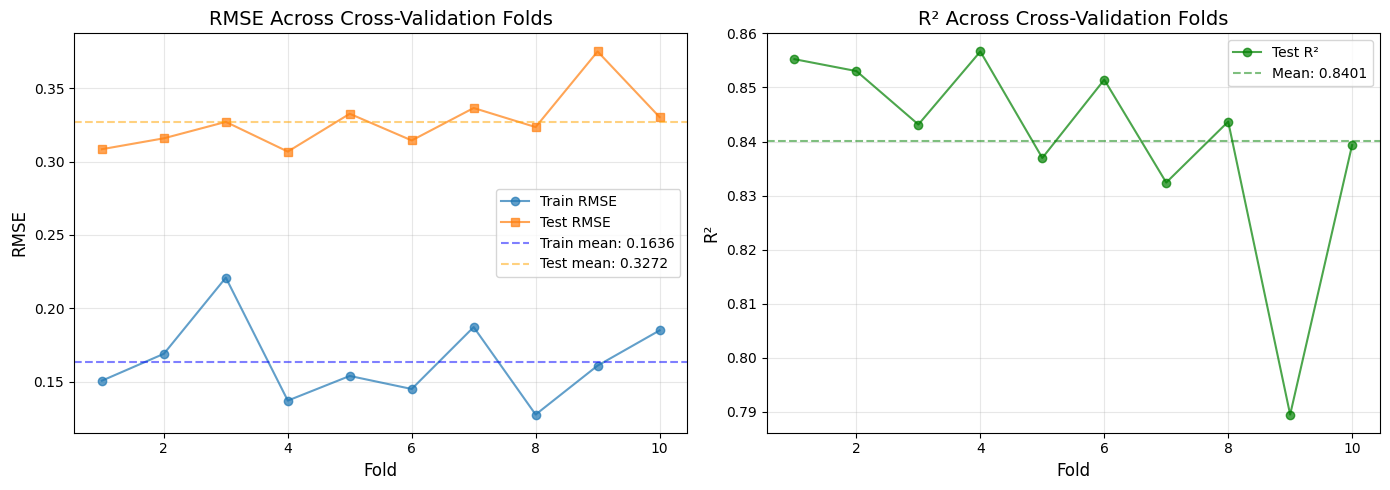

In [18]:
# Optional: Visualize cross-validation results
def plot_cv_results(cv_results):
    """
    Creates visualizations of cross-validation results.
    
    Args:
        cv_results: DataFrame returned by cross_validate_model()
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: RMSE across folds
    ax1 = axes[0]
    ax1.plot(cv_results['fold'], cv_results['train_rmse'], 'o-', label='Train RMSE', alpha=0.7)
    ax1.plot(cv_results['fold'], cv_results['test_rmse'], 's-', label='Test RMSE', alpha=0.7)
    ax1.axhline(cv_results['train_rmse'].mean(), color='blue', linestyle='--', alpha=0.5, label=f'Train mean: {cv_results["train_rmse"].mean():.4f}')
    ax1.axhline(cv_results['test_rmse'].mean(), color='orange', linestyle='--', alpha=0.5, label=f'Test mean: {cv_results["test_rmse"].mean():.4f}')
    ax1.set_xlabel('Fold', fontsize=12)
    ax1.set_ylabel('RMSE', fontsize=12)
    ax1.set_title('RMSE Across Cross-Validation Folds', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: R² across folds
    ax2 = axes[1]
    ax2.plot(cv_results['fold'], cv_results['test_r2'], 'o-', color='green', label='Test R²', alpha=0.7)
    ax2.axhline(cv_results['test_r2'].mean(), color='green', linestyle='--', alpha=0.5, label=f'Mean: {cv_results["test_r2"].mean():.4f}')
    ax2.set_xlabel('Fold', fontsize=12)
    ax2.set_ylabel('R²', fontsize=12)
    ax2.set_title('R² Across Cross-Validation Folds', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize cross-validation results
plot_cv_results(cv_results)

In [ ]:
# Optional: Compare multiple models with cross-validation
# Uncomment to run comparisons:

# models_to_test = ['SingleTaskGP', 'MDN', 'DeepEnsemble']
# cv_comparison = {}

# for model_name in models_to_test:
#     print(f"\n{'='*60}")
#     print(f"Testing {model_name}")
#     print('='*60)
#     cv_comparison[model_name] = cross_validate_model(
#         bf_data, 
#         model_name=model_name,
#         m=10,
#         train_split=0.8,
#         random_state=42
#     )

# # Compare results
# print("\n" + "="*60)
# print("Model Comparison Summary")
# print("="*60)
# for model_name, results in cv_comparison.items():
#     print(f"\n{model_name}:")
#     print(f"  Test RMSE: {results['test_rmse'].mean():.4f} ± {results['test_rmse'].std():.4f}")
#     print(f"  Test R²:   {results['test_r2'].mean():.4f} ± {results['test_r2'].std():.4f}")